In [13]:
import numpy as np
import matplotlib.pyplot as plt


# Stochastic Signal with 30 SNR

Model a signal that corresponds to **P=3**, **Fsig=1 Hz**, **Fs=1 kHz**,
**Amp=1 V**, and **DC=2 V**. Apply noise and model the results

In [19]:
# Parameters for the sinusoidal signal and noise
t = None 

P = 3             
Fsig = 1         
Fs = 1000         
Amp = 1           
DC = 2            

# time vector
t = np.arange(0, P / Fsig, 1 / Fs)

Urms_signal = np.sqrt(DC**2 + (Amp**2) / 2)

SNRdb = 10 

In [23]:
# clean Signal
x_clean = DC + Amp * np.sin(2 * np.pi * Fsig * t)

# required noise power (RMS) to achieve the desired SNR
Urms_noise = Urms_signal / (10 ** (SNRdb / 20))

# generate the noise
noise = Urms_noise * np.random.randn(len(t))

# apple noise to the clean signal
x_noisy = x_clean + noise

# check the results 
true_rms_signal = np.sqrt(np.mean(x_clean**2))
true_rms_noise = np.sqrt(np.mean(noise**2))

achieved_snr = 20 * np.log10(true_rms_signal / true_rms_noise)
print(f"Desired SNR (dB): {SNRdb:.1f}")
print(f"Achieved SNR (dB): {achieved_snr:.1f}")

Desired SNR (dB): 10.0
Achieved SNR (dB): 9.9


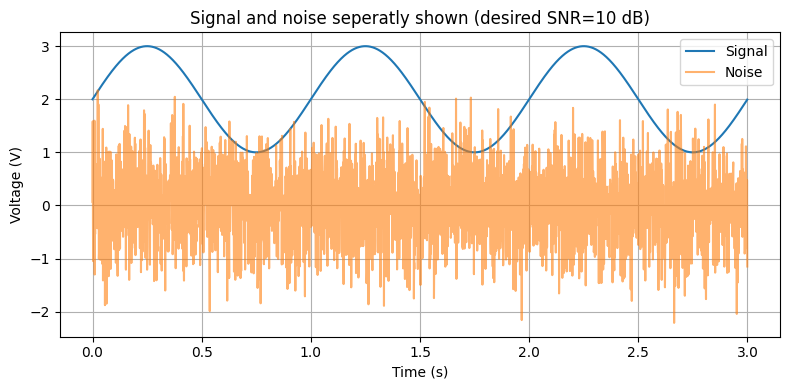

In [16]:
# plot the clean and noisy signals
plt.figure(figsize=(8,4))
plt.plot(t, x_clean, label="Signal")
plt.plot(t, noise, label="Noise", alpha=0.6)
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title(f"Signal and noise seperatly shown (desired SNR={SNRdb} dB)")
plt.grid(True)
plt.legend()
plt.tight_layout()

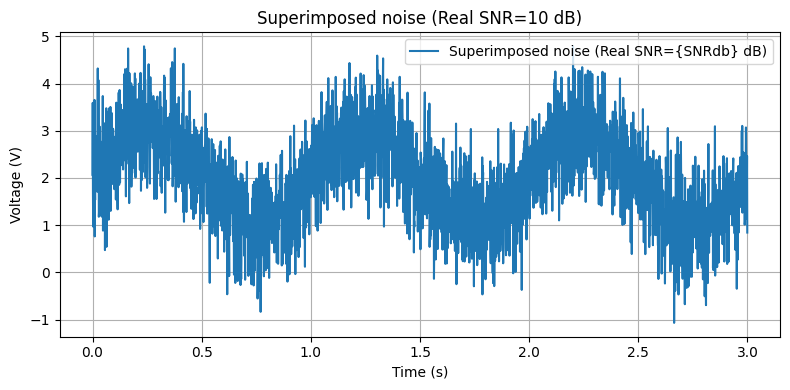

In [17]:
# plot the clean and noisy signals
plt.figure(figsize=(8,4))
plt.plot(t, x_noisy, label="Superimposed noise (Real SNR={SNRdb} dB)")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title(f"Superimposed noise (Real SNR={SNRdb} dB)")
plt.grid(True)
plt.legend()
plt.tight_layout()

/tmp/ipykernel_72952/2512603985.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


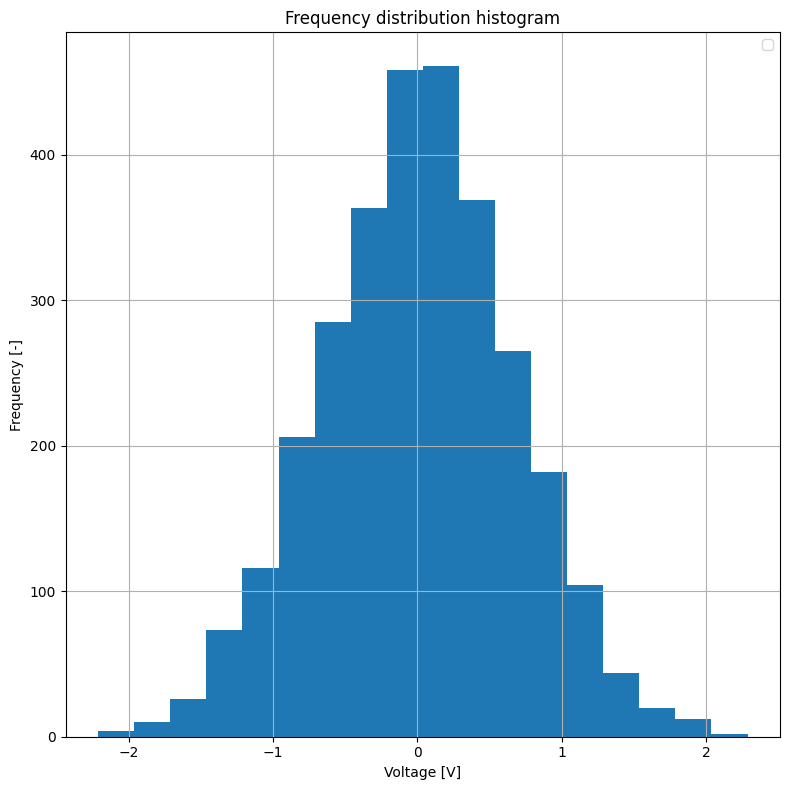

In [18]:
# Frequency distribution histogram with bin width 0.25
plt.figure(figsize=(8,8))
bins = np.arange(np.min(noise), np.max(noise) + 0.25, 0.25)
plt.hist(noise, bins=bins)
plt.xlabel("Voltage [V]")
plt.ylabel("Frequency [-]")
plt.title(f"Frequency distribution histogram")
plt.grid(True)
plt.legend()
plt.tight_layout()
